In [1]:
# miles per gallon dataset
# 1 mile = 1.6 KM
# 1 gallon = 3.7 litre

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df=sns.load_dataset('mpg')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [5]:
df.drop('name', inplace=True, axis=1)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [6]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
dtype: object

In [7]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [8]:
df.horsepower.unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [9]:
df.horsepower.mean()

np.float64(104.46938775510205)

In [10]:
df.horsepower.median()

93.5

In [11]:
df.horsepower.describe()

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

<Axes: ylabel='horsepower'>

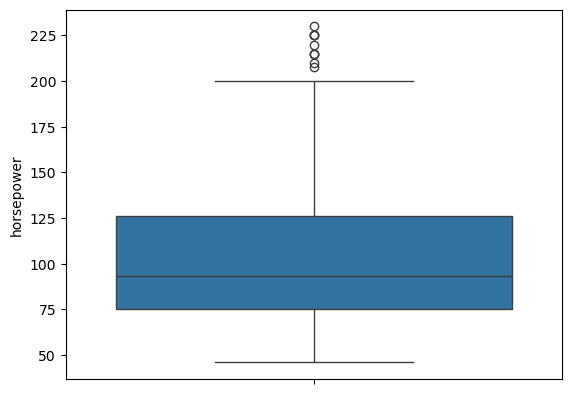

In [12]:
sns.boxplot(df.horsepower)

In [13]:
# since we have not done outlier treatment better to replace median with nan value
df['horsepower']=df['horsepower'].fillna(df['horsepower'].median())

In [14]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [15]:
# data encoding for origin value
df['origin'].value_counts()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

In [16]:
df['origin']=df['origin'].map({'usa':1, 'japan':2, 'europe':3})

In [17]:
df['origin'].value_counts()

origin
1    249
2     79
3     70
Name: count, dtype: int64

In [18]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
dtype: object

In [19]:
X=df.drop('mpg',axis=1)
y=df['mpg']

In [20]:
X

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1
394,4,97.0,52.0,2130,24.6,82,3
395,4,135.0,84.0,2295,11.6,82,1
396,4,120.0,79.0,2625,18.6,82,1


In [21]:
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split as tts
X_train, X_test, y_train, y_test=tts(X, y, test_size=0.3, random_state=1)

In [23]:
X_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
350,4,105.0,63.0,2215,14.9,81,1
59,4,97.0,54.0,2254,23.5,72,3
120,4,121.0,112.0,2868,15.5,73,3
12,8,400.0,150.0,3761,9.5,70,1
349,4,91.0,68.0,1985,16.0,81,2
...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1
255,4,140.0,88.0,2720,15.4,78,1
72,8,304.0,150.0,3892,12.5,72,1
235,4,97.0,75.0,2265,18.2,77,2


In [24]:
X_test

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
174,6,171.0,97.0,2984,14.5,75,1
359,4,141.0,80.0,3230,20.4,81,3
250,8,318.0,140.0,3735,13.2,78,1
274,5,131.0,103.0,2830,15.9,78,3
283,6,232.0,90.0,3265,18.2,79,1
...,...,...,...,...,...,...,...
382,4,108.0,70.0,2245,16.9,82,2
39,8,400.0,175.0,4464,11.5,71,1
171,4,134.0,96.0,2702,13.5,75,2
271,4,156.0,105.0,2745,16.7,78,1


In [25]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model

LinearRegression()

In [26]:
model.fit(X_train, y_train)

LinearRegression()

In [27]:
model.coef_

array([-0.31761423,  0.02623748, -0.01827076, -0.00748775,  0.05040673,
        0.84709514,  1.51909584])

In [28]:
model.intercept_

np.float64(-23.085380742316705)

In [29]:
for i, cname in enumerate(X_train.columns):
    print(f'Coefficient of {cname} is {(model.coef_)[i]}')

Coefficient of cylinders is -0.31761423027992697
Coefficient of displacement is 0.026237482599078894
Coefficient of horsepower is -0.018270764913124512
Coefficient of weight is -0.0074877503983619064
Coefficient of acceleration is 0.05040673461971419
Coefficient of model_year is 0.8470951427061366
Coefficient of origin is 1.519095838797505


In [30]:
# Observation:
# coef_ are relatively smaller, if one independent variable changes there will be not much differnce in prediction
# this is sometimes called as smoother model

# from these many features are not contributing much in model training

In [31]:
from sklearn.metrics import r2_score
y_train_pred=model.predict(X_train)
y_pred_lin=model.predict(X_test)
r2_train=r2_score(y_train, y_train_pred)
r2_test=r2_score(y_test, y_pred_lin)
print(f"Train Rsquare of linear regression is {r2_train}")
print(f"Test Rsquare of linear regression is {r2_test}")

Train Rsquare of linear regression is 0.8125585856350535
Test Rsquare of linear regression is 0.8348001123742286


In [32]:
# regularisation>> ridge regresssion
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=0.1) #alpha is lambda
ridge.fit(X_train, y_train)

Ridge(alpha=0.1)

In [33]:
for i, cname in enumerate(X_train.columns):
    print(f'Coefficient of {cname} is {(ridge.coef_)[i]}')

Coefficient of cylinders is -0.317003210100659
Coefficient of displacement is 0.026213249757982997
Coefficient of horsepower is -0.01826325248144963
Coefficient of weight is -0.0074873260502130775
Coefficient of acceleration is 0.05036896947442412
Coefficient of model_year is 0.8470062938903169
Coefficient of origin is 1.517452828565388


In [34]:
# for ridge regression evaluation
y_pred_ridge=ridge.predict(X_test)
r2_ridge=r2_score(y_test, y_pred_ridge)
print(f"Test Rsquare of ridge regression is {r2_ridge}")

Test Rsquare of ridge regression is 0.8348084889168355


In [35]:
# we do not see much variance in coeff of ridge regression as compared to linear regression

In [36]:
# regularisation>> lasso regresssion
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.5) #alpha is lambda
lasso.fit(X_train, y_train)

Lasso(alpha=0.5)

In [37]:
for i, cname in enumerate(X_train.columns):
    print(f'Coefficient of {cname} is {(lasso.coef_)[i]}')

Coefficient of cylinders is -0.0
Coefficient of displacement is 0.006208198888300369
Coefficient of horsepower is -0.01105838298716959
Coefficient of weight is -0.006982673168023089
Coefficient of acceleration is 0.0
Coefficient of model_year is 0.744654952003819
Coefficient of origin is 0.0


In [38]:
# three feature coefficient is 0, lasso helps in feature selection

In [39]:
# for lasso regression evaluation
y_pred_lasso=lasso.predict(X_test)
r2_lasso=r2_score(y_test, y_pred_lasso)
print(f"Test Rsquare of lasso regression is {r2_lasso}")

Test Rsquare of lasso regression is 0.8277934716635555


In [40]:
# regularisation>> lasso regresssion
from sklearn.linear_model import ElasticNet
elastic=ElasticNet(alpha=1, l1_ratio=0.5) #l1_ratio says how many part lasso and how many part ridge
elastic.fit(X_train, y_train)

ElasticNet(alpha=1)

In [41]:
for i, cname in enumerate(X_train.columns):
    print(f'Coefficient of {cname} is {(elastic.coef_)[i]}')

Coefficient of cylinders is -0.0
Coefficient of displacement is 0.0058888699536675465
Coefficient of horsepower is -0.012403874933570107
Coefficient of weight is -0.00693455051625763
Coefficient of acceleration is 0.0
Coefficient of model_year is 0.7133150744603873
Coefficient of origin is 0.0


In [42]:
# for elastic net regression evaluation
y_pred_elastic=elastic.predict(X_test)
r2_elastic=r2_score(y_test, y_pred_elastic)
print(f"Test Rsquare of elastic net regression is {r2_elastic}")

Test Rsquare of elastic net regression is 0.8284840073256804


In [43]:
# regularization with crossvalidation
from sklearn.linear_model import LassoCV
lasso_cv=LassoCV(cv=5, verbose=2)
lasso_cv

LassoCV(cv=5, verbose=2)

In [44]:
lasso_cv.fit(X_train, y_train)

Path: 000 out of 100
Path: 001 out of 100
Path: 002 out of 100
Path: 003 out of 100
Path: 004 out of 100
Path: 005 out of 100
Path: 006 out of 100
Path: 007 out of 100
Path: 008 out of 100
Path: 009 out of 100
Path: 010 out of 100
Path: 011 out of 100
Path: 012 out of 100
Path: 013 out of 100
Path: 014 out of 100
Path: 015 out of 100
Path: 016 out of 100
Path: 017 out of 100
Path: 018 out of 100
Path: 019 out of 100
Path: 020 out of 100
Path: 021 out of 100
Path: 022 out of 100
Path: 023 out of 100
Path: 024 out of 100
Path: 025 out of 100
Path: 026 out of 100
Path: 027 out of 100
Path: 028 out of 100
Path: 029 out of 100
Path: 030 out of 100
Path: 031 out of 100
Path: 032 out of 100
Path: 033 out of 100
Path: 034 out of 100
Path: 035 out of 100
Path: 036 out of 100
Path: 037 out of 100
Path: 038 out of 100
Path: 039 out of 100
Path: 040 out of 100
Path: 041 out of 100
Path: 042 out of 100
Path: 043 out of 100
Path: 044 out of 100
Path: 045 out of 100
Path: 046 out of 100
Path: 047 out

LassoCV(cv=5, verbose=2)

In [45]:
ypredcv=lasso_cv.predict(X_test)
scorecv=r2_score(y_test, ypredcv)
print(f"Test Rsquare of lasso cv is {scorecv}")

Test Rsquare of lasso cv is 0.808280598384475


In [46]:
# CV with hyperparameter tuning

In [107]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [61]:
# gridsearchcv for lasso
lasso = Lasso()
lasso

Lasso()

In [62]:
# grid search cv>> Dictionary with parameter names(str) as keys and list of parameter settings to try as value
param_grid={'alpha':[0.001, 0.01, 0.1, 1, 10, 100]}
param_grid

{'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [63]:
grid_search=GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='r2', verbose=2)
grid_search

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=2)

In [64]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ........................................

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=2)

In [65]:
grid_search.best_params_

{'alpha': 0.1}

In [66]:
grid_search.best_score_

np.float64(0.7964209726696481)

In [67]:
grid_search.best_estimator_  #estimator that give highest result

Lasso(alpha=0.1)

In [80]:
gly_pred=grid_search.best_estimator_.predict(X_test)
score=r2_score(y_test, gly_pred)
score

0.8345318641232304

In [81]:
# RandomizedSearchCV for lasso
lasso=Lasso()
param_dist={'alpha':[0.001, 0.01, 0.1, 1, 10, 100]}

In [82]:
rand_search=RandomizedSearchCV(estimator=lasso, param_distributions=param_dist,n_iter=3, cv=5, scoring='r2', verbose=2)
rand_search

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=3,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1, 10,
                                                  100]},
                   scoring='r2', verbose=2)

In [86]:
rand_search.fit(X_train, y_train)


Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ...........................................alpha=10; total time=   0.0s
[CV] END ........................................

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=3,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1, 10,
                                                  100]},
                   scoring='r2', verbose=2)

In [87]:
rand_search.best_estimator_

Lasso(alpha=0.1)

In [88]:
rand_search.best_params_

{'alpha': 0.1}

In [89]:
rand_search.best_score_

np.float64(0.7964209726696481)

In [90]:
rly_pred=rand_search.best_estimator_.predict(X_test)
score=r2_score(y_test, rly_pred)
score

0.8345318641232304

In [92]:
# ridge grid search
ridge=Ridge()
param={'alpha':[0.001, 0.01, 0.1, 1, 10, 100]}
ridge

Ridge()

In [93]:
grid_search=GridSearchCV(estimator=ridge, param_grid=param, cv=5, scoring='r2', verbose=2)
grid_search

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=2)

In [94]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ........................................

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=2)

In [95]:
grid_search.best_estimator_

Ridge(alpha=10)

In [96]:
grid_search.best_params_

{'alpha': 10}

In [97]:
grid_search.best_score_

np.float64(0.7943589846334788)

In [98]:
rgy_pred=grid_search.predict(X_test)
score=r2_score(y_test, rgy_pred)
score

0.8354145247502051

In [99]:
# ridge RandomizedSearchCV
ridge=Ridge()
param={'alpha':[0.001, 0.01, 0.1, 1, 10, 100]}

In [100]:
rand_search=RandomizedSearchCV(estimator=ridge, param_distributions=param, cv=5, n_iter=4, scoring='r2', verbose=1)
rand_search

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=4,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1, 10,
                                                  100]},
                   scoring='r2', verbose=1)

In [101]:
rand_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=4,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1, 10,
                                                  100]},
                   scoring='r2', verbose=1)

In [102]:
rand_search.best_estimator_

Ridge(alpha=1)

In [103]:
rand_search.best_score_

np.float64(0.7940502411423692)

In [105]:
rry_pred=rand_search.best_estimator_.predict(X_test)
score=r2_score(y_test, rry_pred)
score

0.8348814925912451

In [109]:
# elasticnet Grid search cv
model=ElasticNet()
param={'alpha':[0.001, 0.01, 0.1, 1, 10, 100],
      'l1_ratio':[0.1, 0.4, 0.9]}
model=GridSearchCV(estimator=elastic, param_grid=param, cv=5, scoring='r2', verbose=1)
model.fit(X_train, y_train)
print(model.best_estimator_)
print(model.best_score_)
rry_pred=model.best_estimator_.predict(X_test)
score=r2_score(y_test, rry_pred)
print(score)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
ElasticNet(alpha=0.1, l1_ratio=0.9)
0.796240922548882
0.8345726087080975


In [110]:
# elasticnet randomizedSearchCV
model=ElasticNet()
param={'alpha':[0.001, 0.01, 0.1, 1, 10, 100],
      'l1_ratio':[0.1, 0.4, 0.9]}
rand_search=RandomizedSearchCV(estimator=model, param_distributions=param, cv=5, n_iter=4, scoring='r2', verbose=1)
rand_search.fit(X_train, y_train)
print(rand_search.best_estimator_)
print(rand_search.best_score_)
rry_pred=rand_search.best_estimator_.predict(X_test)
score=r2_score(y_test, rry_pred)
print(score)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
ElasticNet(alpha=0.001, l1_ratio=0.1)
0.794006070692819
0.8348219639112835
